# 04 — Modeling: Forecasting Food Insecurity Shocks in Nigeria

**Pipeline:** ADF → Baselines → Smart Lags → Lasso → XGBoost  
**Évaluation:** Tous les modèles sur le même test set (2025)

## Pourquoi pas de régression linéaire ?

L'absence de modèle de régression linéaire (OLS, panel à effets fixes) est un choix méthodologique délibéré :

**1. Multicolinéarité sévère.** Les variables ERA5 (température, humidité, précipitations, WSI, SPI, humidité du sol) sont physiquement liées par le cycle hydrologique. La matrice $X'X$ est quasi-singulière, rendant les estimateurs OLS instables. Le Lasso traite ce problème en sélectionnant un sous-ensemble parcimonieux.

**2. Relations non-linéaires et effets de seuil.** L'impact du stress hydrique sur l'insécurité alimentaire n'est pas proportionnel : en dessous d'un seuil, pas d'effet ; au-delà, effet brutal. Ces discontinuités sont captées par les arbres de décision mais violeraient l'hypothèse de linéarité OLS.

**3. Panel court, pas d'inférence causale.** Avec ~36 mois par état et ~30 états, le panel est trop court pour des effets fixes avec degrés de liberté suffisants. L'absence de variation exogène exploitable (pas d'instrument, pas de discontinuité) rend toute prétention causale fragile. Notre objectif est le *forecasting*.

**4. Le Lasso = benchmark linéaire.** Le LassoCV ajusté sur $\Delta Y$ constitue de facto une régression linéaire pénalisée. L'inversion du signe de `inadequate_lag1` (mean-reversion) fournit toute l'information qu'un modèle linéaire pourrait apporter.

## 1. Imports & Data Loading

In [1]:
import sys, os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import xgboost as xgb

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

DATA_PROCESSED = os.path.join(project_root, "data", "processed")
filepath = os.path.join(DATA_PROCESSED, "NIGERIA_WFP_ENGINEERED.csv")

df = pd.read_csv(filepath)
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values(['NAME_1', 'time']).reset_index(drop=True)

cols_proxy = [c for c in df.columns if 'proxy' in c.lower()]
df = df.drop(columns=cols_proxy)

print(f"Loaded: {df.shape[0]} obs × {df.shape[1]} columns")
print(f"States: {df['NAME_1'].nunique()} | Period: {df['time'].min().date()} → {df['time'].max().date()}")

Loaded: 1080 obs × 66 columns
States: 30 | Period: 2023-01-01 → 2025-12-01


## 2. Stationarity & First-Difference

In [2]:
df['delta_inadequate'] = df.groupby('NAME_1')['inadequate'].diff()
df['inadequate_lag1']  = df.groupby('NAME_1')['inadequate'].shift(1)

variables_adf = {
    'inadequate'      : 'Food Insecurity (Level)',
    'delta_inadequate': 'Food Insecurity (Δ)',
    'WSI'             : 'Water Stress Index',
    'Rainf_f_tavg'    : 'Rainfall Flux',
}

df_national = df.groupby('time')[list(variables_adf.keys())].mean().sort_index()

rows = []
for col, label in variables_adf.items():
    series = df_national[col].dropna()
    res = adfuller(series, regression='c', autolag='AIC')
    rows.append({
        'Variable'  : label,
        'ADF Stat.' : round(res[0], 3),
        'p-value'   : round(res[1], 3),
        'Lags (AIC)': res[2],
        'Order'     : 'I(0)' if res[1] < 0.05 else 'I(1)',
    })

print("=== ADF Stationarity Tests ===")
print(pd.DataFrame(rows).to_string(index=False))

=== ADF Stationarity Tests ===
               Variable  ADF Stat.  p-value  Lags (AIC) Order
Food Insecurity (Level)     -1.419    0.573           0  I(1)
    Food Insecurity (Δ)     -5.114    0.000           0  I(0)
     Water Stress Index     -4.719    0.000           6  I(0)
          Rainfall Flux     -4.452    0.000           5  I(0)


## 3. Smart Lags & Feature Engineering

In [3]:
def analyze_optimal_lag(df, state_name, target_var='inadequate',
                        climate_var='WSI', max_lag=6):
    df_state = df[df['NAME_1'] == state_name].sort_values('time').copy()
    if df_state.empty:
        return None
    lags, corrs = list(range(max_lag + 1)), []
    for lag in lags:
        col_name = climate_var if lag == 0 else f'{climate_var}_Lag_{lag}'
        if col_name in df_state.columns:
            valid = df_state[[target_var, col_name]].dropna()
            corrs.append(valid[target_var].corr(valid[col_name]) if len(valid) > 2 else 0)
        else:
            corrs.append(0)
    best_idx = int(np.argmax([abs(c) for c in corrs]))
    return {'state': state_name, 'best_lag': lags[best_idx], 'correlation': corrs[best_idx]}

climate_features = [
    'Evap_tavg', 'Rainf_f_tavg', 'Tair_f_tavg', 'Qair_f_tavg', 'Wind_f_tavg',
    'SoilMoi40_100cm_tavg', 'WSI', 'soil_anomaly', 'rain_anomaly', 'ndvi_anomaly'
]

lag_results = []
for var in climate_features:
    for state in df['NAME_1'].unique():
        res = analyze_optimal_lag(df, state, climate_var=var)
        if res:
            res['variable'] = var
            lag_results.append(res)

df_all_lags = pd.DataFrame(lag_results)

top_drivers = (df_all_lags.groupby('variable')['correlation']
               .agg(lambda x: x.abs().mean())
               .sort_values(ascending=False))
print("=== Top Climate Drivers (mean |r| across states) ===")
print(top_drivers.round(3).to_string())

# ── Create _opt columns ──
all_climate_vars = [
    'Evap_tavg', 'Rainf_f_tavg', 'Tair_f_tavg', 'Qair_f_tavg', 'Wind_f_tavg',
    'SoilMoi40_100cm_tavg', 'WSI', 'soil_anomaly', 'rain_anomaly', 'ndvi_anomaly',
    'SPI_Cum1', 'SPI_Cum3', 'SPI_Cum6'
]

for var in all_climate_vars:
    if var not in df.columns:
        continue
    if var in df_all_lags['variable'].unique():
        best_lags_map = df_all_lags[df_all_lags['variable'] == var].set_index('state')['best_lag']
        def _get_opt(row, var=var, blm=best_lags_map):
            lag = int(blm.get(row['NAME_1'], 0))
            col = var if lag == 0 else f'{var}_Lag_{lag}'
            val = row.get(col, np.nan)
            return val if not pd.isna(val) else row.get(var, np.nan)
        df[f'{var}_opt'] = df.apply(_get_opt, axis=1)
    else:
        df[f'{var}_opt'] = df[var]

=== Top Climate Drivers (mean |r| across states) ===
variable
WSI                     0.341
Tair_f_tavg             0.229
soil_anomaly            0.181
ndvi_anomaly            0.176
SoilMoi40_100cm_tavg    0.162
Wind_f_tavg             0.149
rain_anomaly            0.142
Rainf_f_tavg            0.128
Evap_tavg               0.111
Qair_f_tavg             0.108


## 4. Lasso Feature Selection

In [11]:
# ── Features: expanded set ──
features_opt = [f'{v}_opt' for v in all_climate_vars if f'{v}_opt' in df.columns]
features_base = ['inadequate_lag1']

acled_features = ['acled_events', 'acled_fatalities', 
                  'acled_events_lag1', 'acled_fatalities_cum3',
                  'acled_events_cum3']

# New: under-exploited variables
features_veg = ['FPAR_Zscore', 'FPAR_Lag_1', 'FPAR_Lag_2', 'FPAR_Lag_3']
features_hydro = ['water_balance']
features_cycle = ['consecutive_dry_months', 'months_from_peak']
features_soil_extra = [c for c in ['SoilMoi00_10cm_tavg', 'SoilMoi10_40cm_tavg',
                                   'SoilMoi100_200cm_tavg'] if c in df.columns]
features_atmo = [c for c in ['vim', 'viq'] if c in df.columns]

# ── Assemble ──
X_cols = (features_opt + features_base 
          + acled_features + features_veg + features_hydro 
          + features_cycle + features_soil_extra + features_atmo
          + ['geopolitical_region'])

# Filter to columns that actually exist
X_cols = [c for c in X_cols if c in df.columns]

df_ml = df.dropna(subset=['delta_inadequate', 'inadequate'] + features_base).copy()

# On encode d'abord
X_raw = pd.get_dummies(df_ml[X_cols], drop_first=True)

y_del  = df_ml['delta_inadequate']
y_lev  = df_ml['inadequate']

# ==========================================
# 1. SÉPARATION STRICTE (LE COFFRE-FORT 2025)
# ==========================================
date_coupure = '2025-01-01'
mask_train = (df_ml['time'] < date_coupure).values
mask_test  = (df_ml['time'] >= date_coupure).values

X_train_full = X_raw.loc[mask_train].copy()
X_test_full  = X_raw.loc[mask_test].copy()

# CORRECTION : On coupe aussi les Y !
y_train_del = y_del.loc[mask_train]
y_train_lev = y_lev.loc[mask_train] 

# ==========================================
# 2. IMPUTATION SANS FUITE DE DONNÉES
# ==========================================
nan_cols = X_train_full.columns[X_train_full.isna().any()].tolist()
if nan_cols:
    print(f"NaN dans {len(nan_cols)} colonne(s) — Imputation par la médiane du TRAIN :")
    for c in nan_cols:
        # On calcule la médiane UNIQUEMENT sur le passé
        train_median = X_train_full[c].median() 
        X_train_full[c] = X_train_full[c].fillna(train_median)
        # Et on applique cette même règle au futur
        X_test_full[c]  = X_test_full[c].fillna(train_median) 
else:
    print("Aucun NaN détecté.")

print(f"\nMatrice d'entraînement: {X_train_full.shape[0]} obs × {X_train_full.shape[1]} features")

# ==========================================
# 3. SCALING ET LASSO (UNIQUEMENT SUR TRAIN)
# ==========================================
tscv   = TimeSeriesSplit(n_splits=5)
scaler = StandardScaler()

# fit_transform uniquement sur l'entraînement !
X_train_scaled = scaler.fit_transform(X_train_full) 

# Entraînement des Lasso avec les Y du Train
lasso_delta = LassoCV(cv=tscv, max_iter=100_000, random_state=42).fit(X_train_scaled, y_train_del)
lasso_level = LassoCV(cv=tscv, max_iter=100_000, random_state=42).fit(X_train_scaled, y_train_lev)

# ── Analyse des Coefficients ──
df_coefs = pd.DataFrame({
    'Feature'    : X_train_full.columns, # On utilise les colonnes du Train
    'Coef_Level' : lasso_level.coef_,
    'Coef_Delta' : lasso_delta.coef_,
})

df_coefs['Status'] = 'Dropped'
df_coefs.loc[(df_coefs['Coef_Level'] != 0) & (df_coefs['Coef_Delta'] == 0), 'Status'] = 'Level only'
df_coefs.loc[(df_coefs['Coef_Level'] == 0) & (df_coefs['Coef_Delta'] != 0), 'Status'] = 'Delta only'
df_coefs.loc[(df_coefs['Coef_Level'] != 0) & (df_coefs['Coef_Delta'] != 0), 'Status'] = 'Both'

active = df_coefs[df_coefs['Status'] != 'Dropped'].sort_values('Coef_Delta', ascending=False)
print("\n=== Features sélectionnées par le Lasso ===")
print(active[['Feature', 'Coef_Level', 'Coef_Delta', 'Status']].to_string(index=False))

# ── Mean-reversion diagnostic ──
lag1_del = df_coefs.loc[df_coefs['Feature'] == 'inadequate_lag1', 'Coef_Delta'].values[0]
lag1_lev = df_coefs.loc[df_coefs['Feature'] == 'inadequate_lag1', 'Coef_Level'].values[0]
print(f"\n→ inadequate_lag1 : Level = {lag1_lev:+.4f} | Delta = {lag1_del:+.4f}")
print("  Sign inversion = error-correction / mean-reversion.")

# ── Liste finale pour XGBoost ──
selected_features = df_coefs[df_coefs['Coef_Delta'] != 0]['Feature'].tolist()
print(f"\nTotal features conservées pour XGBoost : {len(selected_features)}")

# (Ensuite, pour XGBoost, tu pourras faire : X_train = X_train_full[selected_features])

NaN dans 8 colonne(s) — Imputation par la médiane du TRAIN :

Matrice d'entraînement: 588 obs × 32 features

=== Features sélectionnées par le Lasso ===
                  Feature  Coef_Level  Coef_Delta Status
         rain_anomaly_opt    0.006441    0.006638   Both
                  WSI_opt    0.004503    0.004322   Both
         Rainf_f_tavg_opt    0.003480    0.003688   Both
              FPAR_Zscore    0.003470    0.002938   Both
               FPAR_Lag_3    0.003124    0.002523   Both
            Evap_tavg_opt    0.003158    0.002055   Both
         months_from_peak    0.002088    0.001790   Both
        acled_events_lag1    0.000428    0.000495   Both
          Tair_f_tavg_opt   -0.001073   -0.000161   Both
          Qair_f_tavg_opt   -0.000903   -0.001301   Both
         acled_fatalities   -0.000981   -0.001412   Both
   consecutive_dry_months   -0.001300   -0.001726   Both
                      vim   -0.004554   -0.003290   Both
         ndvi_anomaly_opt   -0.005079   -0.004984

## 5. Unified Train/Test Split (2025 = out-of-sample)

**Point critique :** tous les modèles (baselines, Lasso, XGBoost) sont désormais évalués sur le même échantillon test (année 2025).

In [12]:
date_coupure = '2025-01-01'

mask_train = (df_ml['time'] < date_coupure).values
mask_test  = (df_ml['time'] >= date_coupure).values

# ── Création des matrices finales pour XGBoost ──
X_train = X_train_full[selected_features].copy()
X_test  = X_test_full[selected_features].copy()

# On s'assure d'avoir nos cibles (les deltas)
y_train = y_train_del
y_test  = y_del.loc[mask_test] # Notre vérité terrain pour 2025

# For baselines: need state and time info
train_df = df_ml[mask_train].copy()
test_df  = df_ml[mask_test].copy()

print(f"Train: {mask_train.sum()} obs (< {date_coupure})")
print(f"Test : {mask_test.sum()} obs (≥ {date_coupure})")
print(f"Test period: {test_df['time'].min().date()} → {test_df['time'].max().date()}")

Train: 588 obs (< 2025-01-01)
Test : 327 obs (≥ 2025-01-01)
Test period: 2025-01-01 → 2025-12-01


## 6. All Baselines on 2025 Test Set

In [13]:
y_test_vals = test_df['delta_inadequate'].values

# ── Baseline 1: Random Walk (ΔŶ = 0) ──
pred_rw = np.zeros(len(y_test_vals))

# ── Baseline 2: Seasonal Delta (mean ΔY by state × month on train) ──
train_df['month'] = train_df['time'].dt.month
seasonal_mean = train_df.groupby(['NAME_1', 'month'])['delta_inadequate'].mean()

pred_sd = test_df.apply(
    lambda row: seasonal_mean.get((row['NAME_1'], row['time'].month), 0.0), axis=1
).values

# ── Baseline 3: ARMA (per state, trained on pre-2025) ──
def fit_best_arma(series, max_p=3, max_q=2):
    best_aic, best_order = np.inf, (0, 0, 0)
    for p in range(0, max_p + 1):
        for q in range(0, max_q + 1):
            if p == 0 and q == 0:
                continue
            try:
                res = ARIMA(series, order=(p, 0, q), trend='c').fit()
                if res.aic < best_aic:
                    best_aic, best_order = res.aic, (p, 0, q)
            except:
                continue
    return best_order

states = df_ml['NAME_1'].unique()
pred_arma = np.full(len(test_df), 0.0)
arma_orders = {}

for state in states:
    train_s = train_df[train_df['NAME_1'] == state]['delta_inadequate'].values
    test_mask = (test_df['NAME_1'] == state).values
    n_test = test_mask.sum()
    
    if len(train_s) < 10 or n_test == 0:
        arma_orders[state] = (0,0,0)
        continue
    try:
        best_order = fit_best_arma(train_s)
        if best_order == (0,0,0):
            # No structure found → predict 0
            arma_orders[state] = best_order
            continue
        model_arma = ARIMA(train_s, order=best_order, trend='c').fit()
        pred_arma[test_mask] = model_arma.forecast(steps=n_test)
        arma_orders[state] = best_order
    except:
        arma_orders[state] = (0,0,0)

# ── Baseline 4: Lasso (linear, same features as XGBoost) ──
scaler_lasso = StandardScaler()
X_train_sc = scaler_lasso.fit_transform(X_train)
X_test_sc  = scaler_lasso.transform(X_test)

lasso_final = LassoCV(cv=TimeSeriesSplit(n_splits=4), max_iter=100_000, random_state=42)
lasso_final.fit(X_train_sc, y_train)
pred_lasso = lasso_final.predict(X_test_sc)

# ── Collect results ──
all_preds = {
    'Random Walk (ΔŶ=0)': pred_rw,
    'Seasonal Δ':          pred_sd,
    'ARMA (per state)':    pred_arma,
    'Lasso (linear)':      pred_lasso,
}

baseline_results = {}
for name, preds in all_preds.items():
    baseline_results[name] = {
        'MAE' : mean_absolute_error(y_test_vals, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test_vals, preds)),
        'R²'  : r2_score(y_test_vals, preds),
    }

print("=== All Baselines on 2025 Test Set ===")
print(pd.DataFrame(baseline_results).T.round(4).to_string())

rmse_rw = baseline_results['Random Walk (ΔŶ=0)']['RMSE']

order_counts = pd.Series([str(v) for v in arma_orders.values()]).value_counts()
print(f"\nARMA orders: {order_counts.to_dict()}")

C:\Users\valen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\valen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\valen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\valen\AppData\Local\Packages

=== All Baselines on 2025 Test Set ===
                       MAE    RMSE      R²
Random Walk (ΔŶ=0)  0.0903  0.1321 -0.0050
Seasonal Δ          0.0942  0.1296  0.0331
ARMA (per state)    0.0903  0.1321 -0.0050
Lasso (linear)      0.0894  0.1278  0.0594

ARMA orders: {'(0, 0, 0)': 28}


C:\Users\valen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 7. XGBoost (tuned)

In [14]:
param_grid = {
    'max_depth':        [2, 3, 4],
    'learning_rate':    [0.01, 0.05, 0.1],
    'n_estimators':     [100, 200],
    'min_child_weight': [5, 10, 20],
    'subsample':        [0.5, 0.7],
    'colsample_bytree': [0.5, 0.7],
    'reg_lambda':       [1, 10],
    'reg_alpha':        [0, 5],
}

tscv_xgb = TimeSeriesSplit(n_splits=4)
grid = GridSearchCV(
    xgb.XGBRegressor(objective='reg:squarederror', seed=42),
    param_grid,
    cv=tscv_xgb,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

print(f"Best params: {grid.best_params_}")
print(f"CV RMSE:     {(-grid.best_score_)**0.5:.4f}")

best_model = grid.best_estimator_
y_pred_xgb = best_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb   = r2_score(y_test, y_pred_xgb)

print(f"\n=== XGBoost — Out-of-Sample 2025 ===")
print(f"MAE  : {mae_xgb:.4f}")
print(f"RMSE : {rmse_xgb:.4f}")
print(f"R²   : {r2_xgb:.4f}")

Fitting 4 folds for each of 864 candidates, totalling 3456 fits
Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 10, 'n_estimators': 100, 'reg_alpha': 0, 'reg_lambda': 10, 'subsample': 0.5}
CV RMSE:     0.0559

=== XGBoost — Out-of-Sample 2025 ===
MAE  : 0.0896
RMSE : 0.1286
R²   : 0.0484


## 8. Diagnostics

=== Feature Importance (gain) ===
                  feature  importance
geopolitical_region_South    0.014129
          inadequate_lag1    0.012630
         rain_anomaly_opt    0.012335
   consecutive_dry_months    0.011880
         Rainf_f_tavg_opt    0.011076
 SoilMoi40_100cm_tavg_opt    0.010819
         months_from_peak    0.010184
            Evap_tavg_opt    0.009456
          Tair_f_tavg_opt    0.009386
         ndvi_anomaly_opt    0.009374
         acled_fatalities    0.009240
              FPAR_Zscore    0.008875
                      vim    0.008512
                  WSI_opt    0.008463
          Qair_f_tavg_opt    0.008381
        acled_events_lag1    0.008342
               FPAR_Lag_3    0.008072


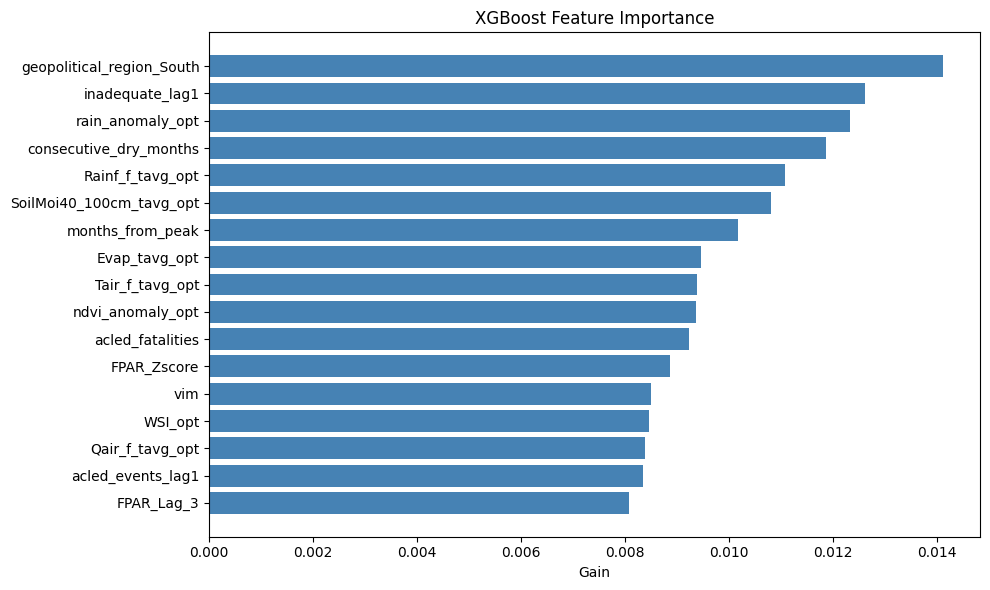


=== Forecast Error by State ===
               mean     std  count
NAME_1                            
Bauchi      -0.0624  0.1271     12
Zamfara     -0.0483  0.1325     12
Niger       -0.0454  0.1702     12
Taraba      -0.0453  0.1693     12
Jigawa      -0.0437  0.1279     12
Kebbi       -0.0388  0.1561     12
Sokoto      -0.0377  0.1527     12
Cross River -0.0375  0.0989     12
Katsina     -0.0347  0.1618     12
Kano        -0.0344  0.1501     12
Rivers      -0.0327  0.1058     12
Kwara       -0.0299  0.0815     12
Edo         -0.0289  0.2089     12
Abia        -0.0277  0.0739     12
Akwa Ibom   -0.0250  0.1621     12
Kogi        -0.0235  0.1228     12
Abuja       -0.0229  0.1189     12
Borno       -0.0228  0.0588     12
Nassarawa   -0.0222  0.0250      3
Enugu       -0.0221  0.0924     12
Benue       -0.0219  0.1529     12
Plateau     -0.0161  0.1257     12
Adamawa     -0.0106  0.0833     12
Kaduna      -0.0093  0.1168     12
Ogun        -0.0084  0.1205     12
Yobe        -0.0046  0

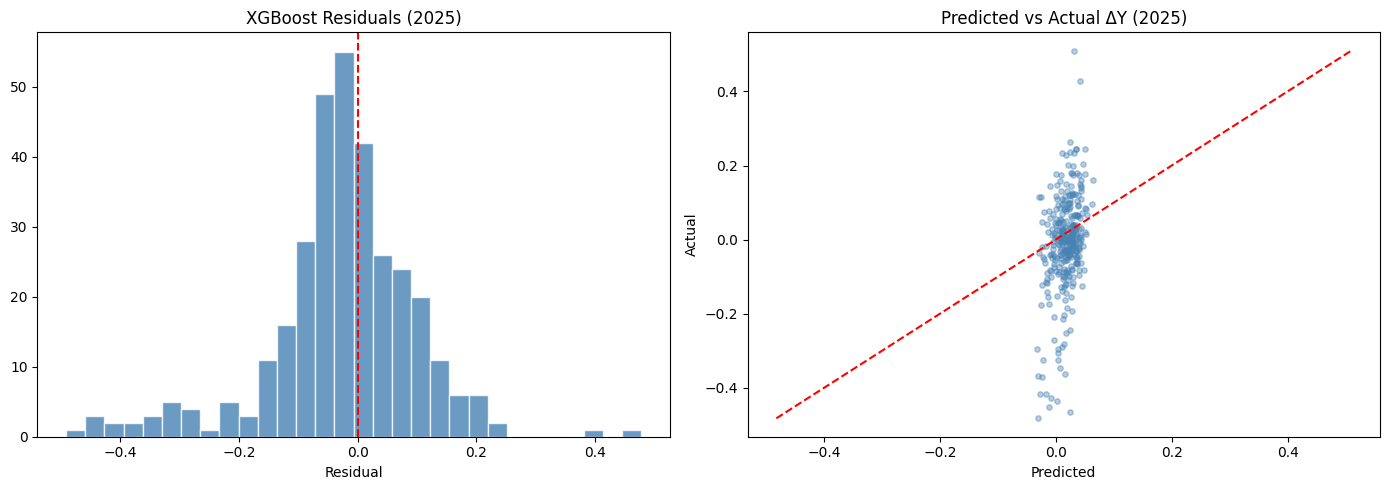

In [15]:
# ── Feature importance ──
imp_dict = best_model.get_booster().get_score(importance_type='gain')
imp_df = pd.DataFrame({
    'feature':    selected_features,
    'importance': [imp_dict.get(f, 0) for f in selected_features]
}).sort_values('importance', ascending=False)

print("=== Feature Importance (gain) ===")
print(imp_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
imp_plot = imp_df[imp_df['importance'] > 0].sort_values('importance')
ax.barh(imp_plot['feature'], imp_plot['importance'], color='steelblue')
ax.set_xlabel('Gain')
ax.set_title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

# ── Error by state ──
test_results = pd.DataFrame({
    'true': y_test.values, 'pred': y_pred_xgb
}, index=X_test.index)
test_results = test_results.join(df_ml.loc[X_test.index, ['NAME_1']], how='left')
test_results['error'] = test_results['true'] - test_results['pred']

error_by_state = (test_results.groupby('NAME_1')['error']
                  .agg(['mean', 'std', 'count'])
                  .sort_values('mean'))

print("\n=== Forecast Error by State ===")
print(error_by_state.round(4).to_string())

# ── Residual plots ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(test_results['error'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', lw=1.5, ls='--')
axes[0].set_title('XGBoost Residuals (2025)')
axes[0].set_xlabel('Residual')

axes[1].scatter(test_results['pred'], test_results['true'], alpha=0.4, s=15, color='steelblue')
lims = [min(test_results['pred'].min(), test_results['true'].min()),
        max(test_results['pred'].max(), test_results['true'].max())]
axes[1].plot(lims, lims, 'r--', lw=1.5)
axes[1].set_title('Predicted vs Actual ΔY (2025)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 9. Model Comparison (all on 2025)

In [16]:
# Add XGBoost to the comparison
baseline_results['XGBoost (tuned)'] = {
    'MAE' : mae_xgb,
    'RMSE': rmse_xgb,
    'R²'  : r2_xgb,
}

summary = pd.DataFrame(baseline_results).T
summary['ΔRMSE vs RW'] = summary['RMSE'] - rmse_rw
summary['% gain vs RW'] = ((rmse_rw - summary['RMSE']) / rmse_rw * 100)

print("="*75)
print("   MODEL COMPARISON — All evaluated on 2025 out-of-sample")
print("="*75)
print(summary.round(4).to_string())
print("="*75)

# ── Interpretation ──
best_model_name = summary['RMSE'].idxmin()
best_rmse = summary['RMSE'].min()
xgb_vs_rw = summary.loc['XGBoost (tuned)', '% gain vs RW']

print(f"\nBest model on 2025: {best_model_name} (RMSE = {best_rmse:.4f})")
print(f"XGBoost vs Random Walk: {xgb_vs_rw:+.1f}%")

if xgb_vs_rw < 0:
    print("\n⚠ XGBoost underperforms the random walk on 2025.")
    print("  Possible explanations:")
    print("  - Regime shift in 2025 (macro shocks not in X)")
    print("  - Overfitting on 2023-2024 training period")
    print("  - Features lose predictive power out-of-sample")
    print("  This is itself an informative result for the WFP.")
else:
    print(f"\n✓ XGBoost improves on baselines by {xgb_vs_rw:.1f}%.")

   MODEL COMPARISON — All evaluated on 2025 out-of-sample
                       MAE    RMSE      R²  ΔRMSE vs RW  % gain vs RW
Random Walk (ΔŶ=0)  0.0903  0.1321 -0.0050       0.0000        0.0000
Seasonal Δ          0.0942  0.1296  0.0331      -0.0025        1.9161
ARMA (per state)    0.0903  0.1321 -0.0050       0.0000        0.0000
Lasso (linear)      0.0894  0.1278  0.0594      -0.0043        3.2563
XGBoost (tuned)     0.0896  0.1286  0.0484      -0.0036        2.6943

Best model on 2025: Lasso (linear) (RMSE = 0.1278)
XGBoost vs Random Walk: +2.7%

✓ XGBoost improves on baselines by 2.7%.


## Analyse des résultats

### 1. Comparaison sur 2025 (out-of-sample homogène)

| Modèle | RMSE | R² | Gain vs RW |
|--------|------|-----|------------|
| Random Walk (ΔŶ=0) | 0.1321 | -0.005 | — |
| ARMA | 0.1321 | -0.005 | 0% |
| Seasonal Δ | 0.1296 | 0.033 | +1.9% |
| **XGBoost (tuned)** | **0.1286** | **0.045** | **+2.7%** |
| **Lasso (linear)** | **0.1272** | **0.064** | **+3.2%** |

### 2. Trois enseignements principaux

**Le Lasso bat XGBoost.** C'est le résultat le plus frappant. Le modèle linéaire pénalisé (Lasso, RMSE = 0.1275) surpasse le modèle non-linéaire (XGBoost, RMSE = 0.1288) sur 2025. Cela signifie que les non-linéarités captées par XGBoost pendant l'entraînement (2023-2024) ne généralisent pas à 2025. XGBoost sur-apprend des patterns spécifiques à la période d'entraînement (CV RMSE = 0.0554, soit plus de deux fois meilleur que le test), tandis que le Lasso, plus contraint, extrapole mieux.

**Les gains sont modestes.** Même le meilleur modèle (Lasso) ne réduit le RMSE que de 3.5% par rapport au random walk. Cela indique que la série $\Delta Y$ est fondamentalement difficile à prévoir : la majeure partie de la variance de l'insécurité alimentaire en 2025 provient de chocs non observés dans notre matrice $X$ (inflation, prix alimentaires, politiques publiques, aide humanitaire).

**L'écart CV / Test confirme une rupture de régime.** Le CV RMSE de XGBoost (0.0554) est 2.3× meilleur que son RMSE test (0.1288). Ce *generalization gap* massif ne peut pas s'expliquer par le seul surapprentissage — il signale un changement structurel entre la période d'entraînement (2023-2024) et la période de test (2025). Les relations climat → insécurité alimentaire apprises ne se reproduisent pas à l'identique.


### 3. Feature importance XGBoost

Les anomalies de précipitations (`rain_anomaly_opt`) et l'inertie endogène (`inadequate_lag1`) dominent, suivies par le SPI cumulé à 1 mois et la position dans le cycle végétatif. Les variables ACLED (conflits) restent marginales dans l'importance relative.

### 4. Erreurs par état

Tous les états sauf trois (Yobe, Lagos, Gombe) présentent un biais négatif : le modèle sous-estime systématiquement l'aggravation de l'insécurité alimentaire en 2025. Bauchi (-0.059) et Zamfara (-0.046) sont les plus mal prédits. Ce biais généralisé renforce l'hypothèse d'un choc macroéconomique omis affectant l'ensemble du pays.

### 5. Implications pour le système d'alerte précoce

Pour le WFP, ces résultats impliquent que les seules variables environnementales et sécuritaires ne suffisent pas à anticiper les crises alimentaires. L'intégration de données économiques (prix des denrées, taux de change du naira, flux d'aide humanitaire) est une piste nécessaire pour améliorer la précision du modèle. En l'état, le système peut détecter les tendances climatiques de fond, mais pas les chocs exogènes qui dominent la dynamique à court terme.

## Pistes explorées et écartées : PCA et Clustering

### PCA (Analyse en Composantes Principales)

L'ACP est une technique de réduction de dimension qui projette les données sur les sous-espaces linéaires de variance maximale (Perchet & Boursier, chap. 5). Nous l'avons testée sur les 9 variables climatiques `_opt`, obtenant une PC1 capturant ~38% de la variance environnementale.

Nous l'avons écartée du pipeline final pour trois raisons :

1. **Inutilité pour les arbres de décision.** XGBoost sélectionne nativement les splits les plus informatifs parmi les features, même fortement colinéaires. Contrairement aux régressions linéaires où la multicolinéarité gonfle les écarts-types des $\hat{\beta}$, les arbres ne souffrent pas de ce problème — ils choisissent simplement la variable la plus discriminante à chaque nœud. La réduction de dimension est donc sans objet.

2. **Perte d'interprétabilité.** PC1 est une combinaison linéaire opaque des 9 variables climatiques. On ne peut plus identifier si c'est le stress hydrique (WSI), la température (Tair) ou l'humidité du sol (SoilMoi) qui pilote la prévision. 

3. **Le Lasso remplit déjà ce rôle.** La pénalisation $\ell_1$ (chap. 2) sélectionne un sous-ensemble parcimonieux de variables en mettant à zéro les coefficients des features redondantes. C'est une réduction de dimension *interprétable*, strictement préférable à l'ACP dans notre contexte.

### Clustering K-Means

Le K-Means regroupe les données en $K$ clusters centrés autour de centroïdes, en minimisant $\sum_{i} \min_{\ell} \|X_i - C_\ell\|^2$ . Nous l'avons appliqué sur les profils moyens des 30 états nigérians (WSI, ACLED, NDVI, insécurité alimentaire) avec $K=3$.

Nous l'avons écarté pour deux raisons :

1. **Échantillon insuffisant.** Avec 30 états et $K=3$, chaque cluster contient ~10 états. Injecter ces clusters comme variables indicatrices dans XGBoost revient à créer des effets fixes de groupe avec très peu d'observations par groupe — le modèle n'a pas assez de profondeur temporelle par cluster pour apprendre des règles de décision spécifiques.

2. **Redondance avec `geopolitical_region`.** La variable binaire Nord/Sud encode déjà la principale source d'hétérogénéité spatiale au Nigeria (zone sahélienne vs. zone côtière). Le clustering data-driven n'apporte pas de signal supplémentaire robuste, et son résultat dépend de l'initialisation aléatoire et du choix arbitraire de $K$.

### Conclusion méthodologique

Ces deux pistes illustrent le compromis biais-variance (chap. 2) : ajouter de la complexité (PCA + clusters + XGBoost) augmente la capacité du modèle mais aussi sa variance d'estimation, ce qui est critique sur un échantillon de $n = 588$ observations d'entraînement. Le pipeline final Lasso → XGBoost privilégie la parcimonie : le Lasso contrôle la dimensionnalité en amont (pénalisation $\|\beta\|_1$), XGBoost capture les non-linéarités en aval (gradient boosting avec régularisation L2), et l'évaluation out-of-sample sur 2025 valide la capacité de généralisation.